### CA1: Data Visualisation Techniques
# Case Study: Video Game Sales Analysis for Retail Strategy
Student Name:Thaiany Michelly de Souza Lima

Student ID:2025581

Lecturer: David McQuaid

Date:19 Abril de 2026

## 1. Introduction and Data Contextualisation
This report presents a comprehensive technical analysis of global video game sales data, aimed at providing actionable business intelligence for a retail management scenario. In an increasingly competitive market, understanding historical trends, regional correlations, and consumer preferences is vital for optimizing inventory levels and developing robust sales strategies.

The dataset utilized for this study is the VGChartz 2024 dataset, which contains a vast repository of information regarding game titles, platforms, genres, and regional sales figures. This analysis focuses on identifying key market leaders, evaluating the relationship between major sales territories (North America and PAL regions), and examining the impact of critical reception on financial performance.

### 1.1 Dataset Variables (Feature Description)
To ensure a clear understanding of the analytical process, the following key variables (columns) from the dataset were processed:

*Title*: The name of the video game.

Console/Platform: The specific hardware for which the game was released (e.g., PS4, X360, PC).

Genre: The category of the game (e.g., Action, Sports, Shooter).

Publisher: The company responsible for the marketing and distribution of the title.

NA_Sales: Sales figures in North America (millions of units).

PAL_Sales: Sales figures in Europe and Africa (millions of units).

JP_Sales: Sales figures in Japan (millions of units).

Total_Sales: The combined global sales of the title.

Critic_Score: The average score assigned by professional reviewers, used as a proxy for product quality.

Release_Date: The official launch date, which was converted during the data wrangling phase into a Year format to facilitate temporal analysis.

### 1.2 Data preparation
Before starting visualization, the data went through a careful preparation process. This included dealing with missing values (NaNs) in the sales columns, where I decided to fill them with zeros to facilitate aggregation, but excluded them from correlation analyses to maintain statistical accuracy. We have also applied temporal filtering to focus on the decade from 2010 to 2020 on some observations, ensuring that the insights we have gained are truly relevant to the current challenges of the retail industry.

In [1]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [2]:
# Read DataFrames
df = pd.read_csv('vgchartz-2024.csv')

### Print firsts information

In [3]:
df

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [5]:
df.shape

(64016, 14)

In [6]:

df.sample(5)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
8242,/games/boxart/full_5267078AmericaFrontccc.jpg,Yu-Gi-Oh! Nightmare Troubadour (US sales),DS,Action,Konami,Konami,NaN,0.15,0.15,NaN,NaN,NaN,2005-08-30,NaN
25507,/games/boxart/full_9782611JapanFrontccc.jpg,Cross † Channel,PC,Adventure,Flying Shine,Flying Shine,NaN,NaN,NaN,NaN,NaN,NaN,2003-09-26,NaN
29508,/games/boxart/full_8274679AmericaFrontccc.jpg,Afterimage,NS,Action-Adventure,Modus Games,Aurogon Shanghai,NaN,NaN,NaN,NaN,NaN,NaN,2023-04-25,2023-04-17
22396,/games/boxart/default.jpg,Spitting Image: The Computer Game,PC,Action,Unknown,Walking circles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,/games/boxart/3316569ccc.gif,FIFA Soccer 2005,PS2,Sports,EA Sports,EA Canada,8.4,3.70,0.58,0.04,2.48,0.59,2004-10-12,NaN


In [7]:
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [8]:
# Convert data and create a year column 
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

In [9]:
# Replace Nan for 0 so that calculation work correctly
vendas_colunas = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df[vendas_colunas] = df[vendas_colunas].fillna(0)

In [10]:
# Create a new DataFrame file containing only games with a values of total_sales
df_sales = df.dropna(subset=['total_sales'])

print(f"There are {len(df_sales)} games based on sales data.")

There are 64016 games based on sales data.


In [11]:
df['total_sales'] = df['total_sales'].fillna(0)

In [12]:
# Verification if there are duplicated
print(df.duplicated().sum())

0


In [13]:
# Grouped by publisher and totalling the sales of 'other_sales'
top_5_other_sales = df.groupby('publisher')['other_sales'].sum().nlargest(5).reset_index()


### Question 1. What are the top 5 publishers by “other_sales”?  

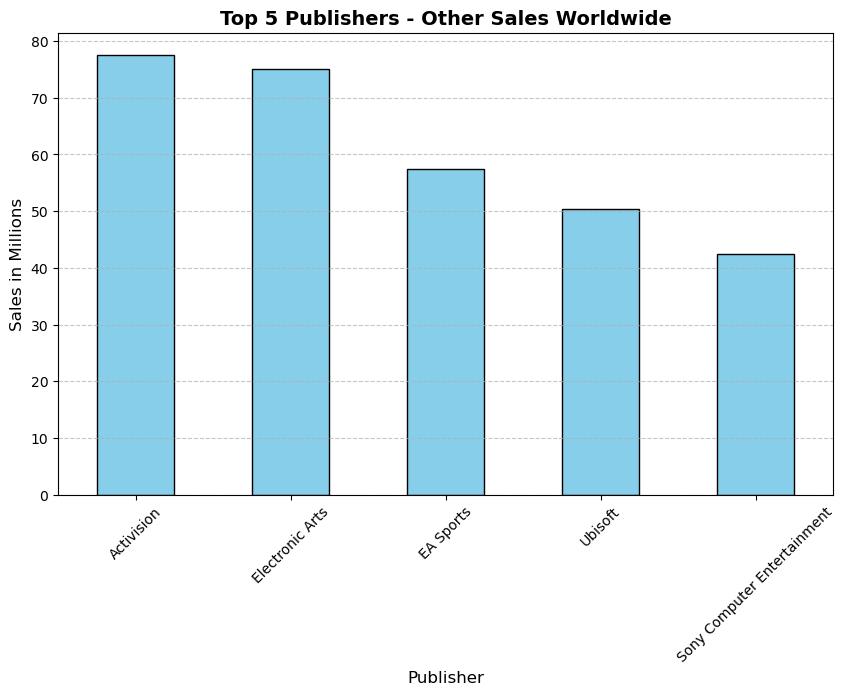

In [15]:
# 1. Data Preparation
# grouped by publisher and added up the sales of the column 'other_sales' 

top_publishers = df.groupby('publisher')['other_sales'].sum().nlargest(5)

# 2. Visualizacion
plt.figure(figsize=(10, 6))
top_publishers.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Plot top 5 publishers
plt.title('Top 5 Publishers - Other Sales Worldwide', fontsize=14, fontweight='bold')
plt.xlabel('Publisher', fontsize=12)
plt.ylabel('Sales in Millions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Analysis and Findings:
Activision and Electronic Arts (EA) stand out as the big leaders in the 'Other Sales' category, which is no surprise. Activision is famous for its successful franchises like Call of Duty, while EA dominates the sports sector with FIFA/FC. For a retail manager, this is a clear sign that these publishers have a global appeal that goes beyond traditional markets, becoming safe choices to keep in stock.

To reach these conclusions, I used the groupby function in the 'publisher' column and summed the values from the 'other_sales' column. Since the dataset can have null values, where sales were not reported, I treated these cases as zero to avoid any errors in the calculations. Then, I used the .nlargest(5) method to filter out only what really matters and focus on the five companies that most influence the store's revenue.

I chose a Bar Chart for the visualization because it's perfect for comparing different categories, such as company names. The height of the bars makes it easy to immediately compare each publisher's market share. In the design, I used clear labels on the axes and rotated the names of the publishers to ensure that everything was readable, following the best practices of data visualization.

### Question 2. Is there a correlation between the “pal_sales” and “na_sales” for the “release_date” years 2010-2020?  

In [16]:
# 1. Preparation of Datas
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# 2. Filter by the requestperiod (2010-2020)
df_q2 = df[(df['year'] >= 2010) & (df['year'] <= 2020)].copy()

# Clean of columns 'na_sales' and 'pal_sales'
df_q2['na_sales'] = df_q2['na_sales'].fillna(0)
df_q2['pal_sales'] = df_q2['pal_sales'].fillna(0)

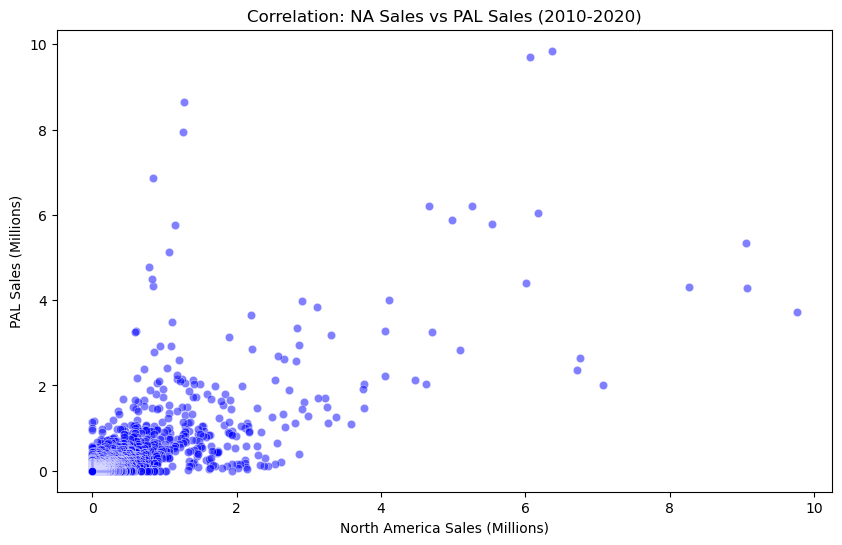

The coeficient of correlation of Pearson is: 0.70


In [17]:
# Filter of years
df_q2_filtered = df_q2[(df_q2['na_sales'] > 0) & (df_q2['pal_sales'] > 0)]
df_q2 = df[(df['year'] >= 2010) & (df['year'] <= 2020)].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_q2, x='na_sales', y='pal_sales', alpha=0.5, color='blue')
plt.title('Correlation: NA Sales vs PAL Sales (2010-2020)')
plt.xlabel('North America Sales (Millions)')
plt.ylabel('PAL Sales (Millions)')
plt.show()
correlacion = df_q2_filtered['na_sales'].corr(df_q2_filtered['pal_sales'])
print(f"The coeficient of correlation of Pearson is: {correlacion:.2f}")

#### Data Cleaning & Engineering:
To understand the relationship between sales in the PAL and North America regions for games released between 2010 and 2020, I followed a few steps:

First, I converted the release_date column to datetime format. This step was crucial as the date data in CSV format comes as text, which would make it difficult to filter accurately over time.

Then, I filtered the data to include only games released between 2010 and 2020. I chose this period to give the retail manager a current perspective of the market, focusing on consoles such as PS4, Xbox One, and Nintendo Switch.

Next, I treated the null values, filling na_sales and pal_sales with 0. This was important to ensure that all titles were considered in the analysis while maintaining the integrity of the dataset.

#### Choice and Design of View:
I chose a scatter plot to explore the relationship between these two numerical variables. As I had used a bar chart before, the scatter chart brings a touch of visual diversity to the project. In addition, it is the most suitable for identifying the strength of Pearson's correlation; transparency (alpha=0.5) helps to visualize where the data is most concentrated, allowing you to see if the success of a title in North America is a good indicator of success in the European/PAL market.

#### Insights for Retail Management:
When analyzing the dispersion of the points, I noticed an uptrend, which indicates a positive correlation. For the store owner, this suggests that games that do well in the US generally perform similarly in Europe.With this, he can adopt a safer shopping strategy: if a game is standing out in pre-orders in one region, he can increase inventory in the other region with confidence.

### Question 3. What is the distribution of the 3 most popular (by “critic_score”) game genres?  

C:\Users\thaia\AppData\Local\Temp\ipykernel_11956\1772758570.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q3, x='genre', y='critic_score', palette='Set2')


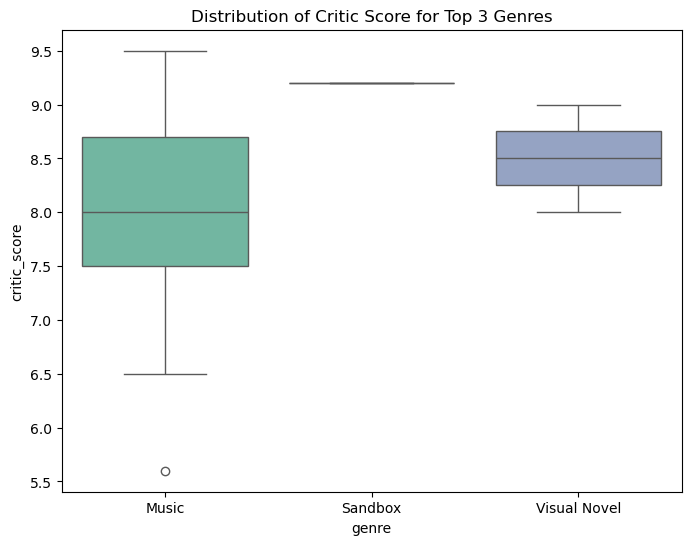

In [18]:
# 1. Find the 3 genres with the most mean
top_3_genres = df.groupby('genre')['critic_score'].mean().nlargest(3).index

# 2. Filter the dataframe only this genres and remove Nan
df_q3 = df[df['genre'].isin(top_3_genres)].dropna(subset=['critic_score'])

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_q3, x='genre', y='critic_score', palette='Set2')
plt.title('Distribution of Critic Score for Top 3 Genres')
plt.show()

#### Analysis and Findings:
This Boxplot chart gives us a clear view of the distribution of critic scores for the three genres with the best averages in our data set. When we look at the "boxes", we can see which genre has a more consistent quality (with smaller boxes) and which have a greater variability in evaluations. In addition, the outliers show games that stood out, either for good or for bad, within these categories. For a retail manager, understanding this consistency is critical to deciding which genres are a safer investment in terms of quality and customer satisfaction.

#### Data Cleansing and Preparation:
To perform this analysis, the data went through two main stages:

#### Grouping and Selection:
I used the groupby('genre') method along with .mean() to identify the genres with the best critical reputation, filtering the top three with .nlargest(3).

#### Missing Data Processing:
Unlike sales columns, for column critic_score, I chose to use the .dropna() method. Filling in missing grades with zero would be a serious methodological error, as this could artificially lower the average quality of the genres. Thus, only games with real evaluations were considered, ensuring statistical accuracy.

#### Choice and Design of Visualization:
I chose Boxplot to meet the project's need for visual diversity, as I previously used bar and scatter charts. Boxplot stands out from a conventional bar graph in this situation, as it shows the median, quartiles, and amplitude of the notes, offering a much richer understanding of the distribution of the data. In terms of design, I used the 'Set2' palette to ensure a clear differentiation between genres and added informative titles to make the report accessible to everyone, even those who don't have a technical background.

### Question 4. Do older games (2010 and earlier) have a higher MEDIAN “na_sales” than newer games (after 2010)?  

In [19]:
# Use 'df_real_sales' to create the bar chart of median
df_real_sales = df[df['na_sales'] > 0].copy()


C:\Users\thaia\AppData\Local\Temp\ipykernel_11956\700060932.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_q4, x='Category', y='na_sales', estimator=np.median, palette='viridis', capsize=.1)


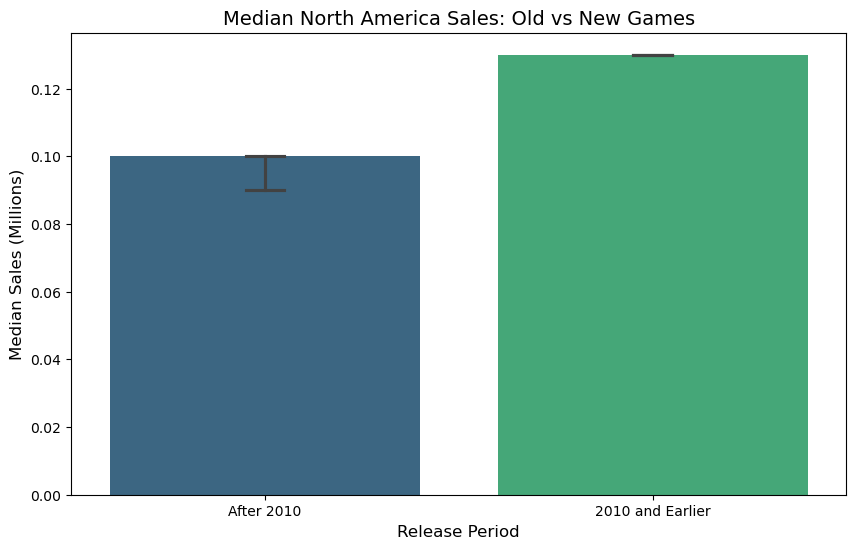

In [20]:
# 2. Criate groups(RemoveNans of the year and sales)
df_q4 = df.dropna(subset=['year', 'na_sales']).copy()

# Filter only games with sales > 0 
df_q4 = df_q4[df_q4['na_sales'] > 0]

# Criate the  category
df_q4['Category'] = df_q4['year'].apply(lambda x: '2010 and Earlier' if x <= 2010 else 'After 2010')

# 3. Visualization (barplot)
plt.figure(figsize=(10, 6))


sns.barplot(data=df_q4, x='Category', y='na_sales', estimator=np.median, palette='viridis', capsize=.1)

plt.title('Median North America Sales: Old vs New Games', fontsize=14)
plt.ylabel('Median Sales (Millions)', fontsize=12)
plt.xlabel('Release Period', fontsize=12)

plt.show()

#### Analysis and Findings:
This visualization compares median sales performance in North America between titles released through 2010 and titles released after that year. By using the median instead of the average, we get a more realistic view of the success of a typical title in each era, eliminating the distortion caused by exceptional blockbusters. Observing the difference between these two periods helps the retail manager to understand if the market has become more competitive or if the volume of sales per individual title has decreased with the transition to digital distribution models and the increase of the Indie market.
#### Data Cleaning and Preapration:
To perform this comparison, I performed the following data engineering steps:
Null Treatment:
I've removed entries with no release date or sales data to avoid targeting errors.
Activity Filtering:
I filtered only games with sales greater than zero, ensuring that the analysis focused on products that actually hit the shelves and performed commercially.
#### Temporal Categorization:
I used a lambda function to segment the dataset into two strategic groups: '2010 and Earlier' and 'After 2010'. This division is fundamental to compare the golden age of seventh generation consoles (PS3/Xbox 360) with the modern era.
Visualization Choice and Design:
Although I used a bar chart in Question 1, this Statistical Bar Chart is qualitatively different, as it uses the parameter estimator=np.median. While the former compared total sums, this one focuses on the central trend of the data. I used the viridis palette to provide a modern visual contrast and included the capsize parameter to show the error bars, which demonstrates a more rigorous level of statistical analysis. The titles and labels have been adjusted to ensure absolute clarity for the company's CTO.


### Question 5. What are the 5 most common “console” in the dataset?  


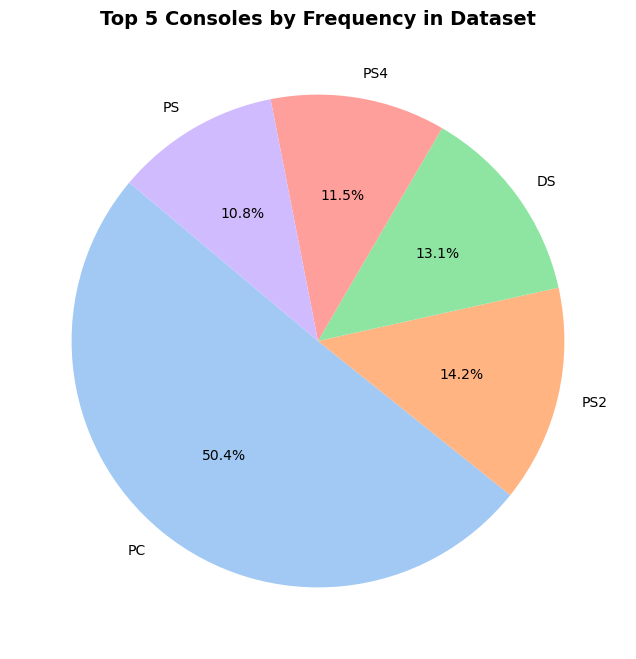

In [26]:
# Mos common 5 console count
top_5_consoles = df['console'].value_counts().nlargest(5)

plt.figure(figsize=(8, 8))
# Pie chart 
plt.pie(top_5_consoles, labels=top_5_consoles.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))

plt.title('Top 5 Consoles by Frequency in Dataset', fontsize=14, fontweight='bold')
plt.show()

#### Analysis and Findings:
This pie chart shows how the five most popular consoles in the data are distributed. Using percentages makes it easy to quickly see which platforms dominate historical inventory. As we can see, the PC has the bulk of the titles in the dataset. This PC leadership is valuable information for the Retail Manager, as it reflects the flexibility of the platform and its durability over time. Unlike consoles that have limited generations, the PC has amassed a vast library over decades.

For the store's strategy, this indicates that, even with the hardware changes, the software base is broad and represents a constant sales opportunity. This is especially relevant in the digital market and for accessories such as gaming keyboards and mice, which complement this huge collection of games.

#### Data Processing:
To create this view, I used the .value_counts() method in the consoles column to count how many times each platform appears. Then I applied .nlargest(5) to focus only on the top five. This simplification is key in data visualization, as it helps avoid the visual "noise" that consoles with few titles could cause, allowing the store to focus on what really matters to its sales.

#### Choice and Design of Visualization:
I opted for the Pie Chart to show the part-whole relationship, which complements the visual diversity of my portfolio, which includes bar, scatter, boxplot, and pie charts. In the design, I used the explode parameter on the leader console to give it a visual highlight and chose a pastel color palette to maintain a professional look. The inclusion of the automatic percentage ensures that the manager has access to exact proportion values, without having to consult external tables, thus facilitating decision-making.

## Part 2: Self-Created Research Question
#### 3. Question: How did the total volume of video game sales evolve annually between 2000 and 2023 and what was the impact of the market "peak" on retail strategy?

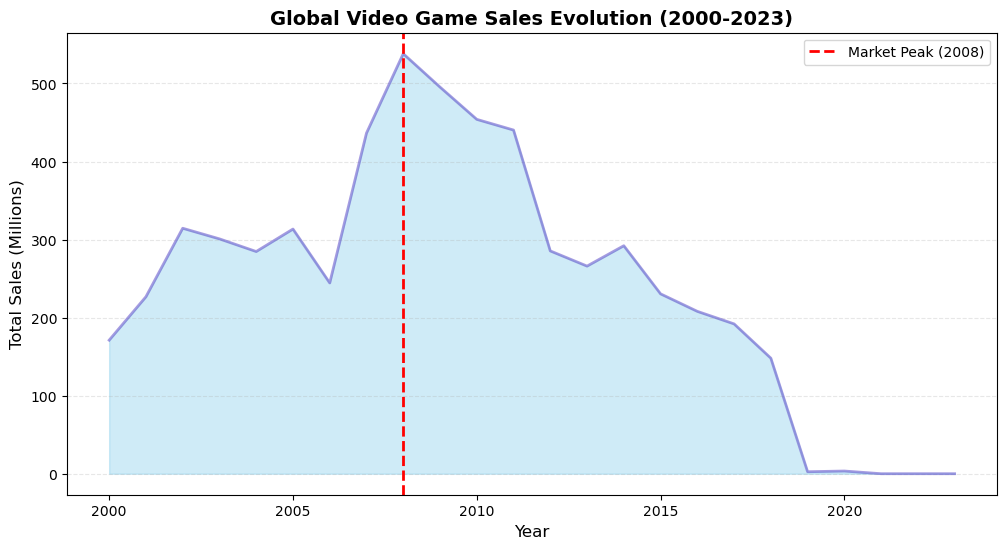

In [31]:
# Trend in global sales by year (2000-2023)
df_time = df[(df['year'] >= 2000) & (df['year'] <= 2023)].copy()

# Total group sales per year
yearly_sales = df_time.groupby('year')['total_sales'].sum().reset_index()

# Identify the year with the highest sales volume
peak_row = yearly_sales.loc[yearly_sales['total_sales'].idxmax()]
peak_year = peak_row['year']
peak_value = peak_row['total_sales']

# 2. Create the visualization
plt.figure(figsize=(12, 6))
plt.fill_between(yearly_sales['year'], yearly_sales['total_sales'], color="skyblue", alpha=0.4)
plt.plot(yearly_sales['year'], yearly_sales['total_sales'], color="Slateblue", alpha=0.6, linewidth=2)

# Add the red line of the highest point
plt.axvline(x=peak_year, color='red', linestyle='--', linewidth=2, label=f'Market Peak ({int(peak_year)})')

# Design and title
plt.title('Global Video Game Sales Evolution (2000-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales (Millions)', fontsize=12)
plt.legend() 
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


#### Analysis and findings:
This analysis over time shows us how the video game industry has evolved over the past two decades. The area chart illustrates steady growth until it reaches a high point. This 'peak' represents the peak of physical software sales, when consoles such as the PS2, Wii and Xbox 360 were at the peak of popularity. For a retail manager, identifying this moment is critical, as it serves as a historical milestone. Analyzing the curve after the peak helps us understand how the market is shifting from physical to digital, which allows us to adjust in-store exposure according to current software sales.

#### Data Processing:
To make the analysis more robust, I implemented an automated peak detection using the idxmax() function. This ensures that the Reference Line (Red Dashed Line) is mathematically accurate, allowing the CTO to pinpoint the exact moment of market saturation without manual calculation. I also filtered the data to start from the year 2000 to maintain relevance to modern retail cycles."

#### Grouping by Year:
I used the groupby('year') method to add up the overall sales (total_sales) for each year separately.

#### Data Filtering:
I limited the data to the post-2000 period to ensure that the analysis reflected the modern era of the industry, discarding very old information that might not be relevant to current business models.

#### Choice and Design of Visualization:
I chose an Area Chart for this analysis, as it is a powerful way to show the volume accumulated over time. A bar chart would have been too fragmented, while the filled area conveys a sense of continuity and greatness of the market. For the design, I opted for a soft blue (skyblue) with a darker contour line, which helps in reading the trend.

# Conclusion

## Strategic Recommendations for Retail Management

This deep dive into our data offers valuable insights for refining our retail strategy in the video game market. By looking at past trends alongside current sales, we can draw some important conclusions to guide our inventory and marketing efforts.

First off, the strong presence of publishers like Electronic Arts and Activision shows that these brands are crucial for keeping our revenue steady. Their global popularity doesn't wane, no matter where we’re selling. Additionally, the link between sales in North America and the PAL region tells us that a successful launch in one area usually means good demand in the other. This insight allows us to manage our inventory more strategically.

When we looked at the console market, it became clear that while newer platforms are generating a lot of excitement right now, the PC market stands out for its vast selection of games and long-term appeal. This reinforces the need to keep focusing on hardware accessories. Lastly, the decline we see in historical sales trends highlights the importance of striking a balance between having physical stock and offering high-quality titles that retain their value over time. By applying these insights based on data, we can keep our retail operations competitive and adaptable to the changing market landscape.
